<a href="https://colab.research.google.com/github/adityarizqiqa/244107020008-machine-learning/blob/main/Tugas_JS4_KMeans_DBSCAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.datasets import make_moons
from sklearn.metrics import (silhouette_score, homogeneity_score, completeness_score,
                              v_measure_score, adjusted_rand_score, adjusted_mutual_info_score)

plt.rcParams["figure.dpi"] = 110


In [2]:
from google.colab import files

uploaded = files.upload()
csv_name = list(uploaded.keys())[0]
df = pd.read_csv(csv_name)

print("Shape:", df.shape)
df.head()


Saving Mall_Customers.csv to Mall_Customers.csv
Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.describe()


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [4]:
features = ["Annual Income (k$)", "Spending Score (1-100)"]
X = df[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [5]:
K_range = range(2, 11)
inertias = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

best_k = list(K_range)[int(np.argmax(sil_scores))]
print("Silhouette per k:")
for k, s, i in zip(K_range, sil_scores, inertias):
    print(f"  k={k}: silhouette={s:.4f}, inertia={i:.2f}")
print(f"\nBest k (silhouette tertinggi) = {best_k}")


Silhouette per k:
  k=2: silhouette=0.3213, inertia=269.69
  k=3: silhouette=0.4666, inertia=157.70
  k=4: silhouette=0.4939, inertia=108.92
  k=5: silhouette=0.5547, inertia=65.57
  k=6: silhouette=0.5399, inertia=55.06
  k=7: silhouette=0.5281, inertia=44.86
  k=8: silhouette=0.4552, inertia=37.23
  k=9: silhouette=0.4571, inertia=32.39
  k=10: silhouette=0.4432, inertia=29.98

Best k (silhouette tertinggi) = 5


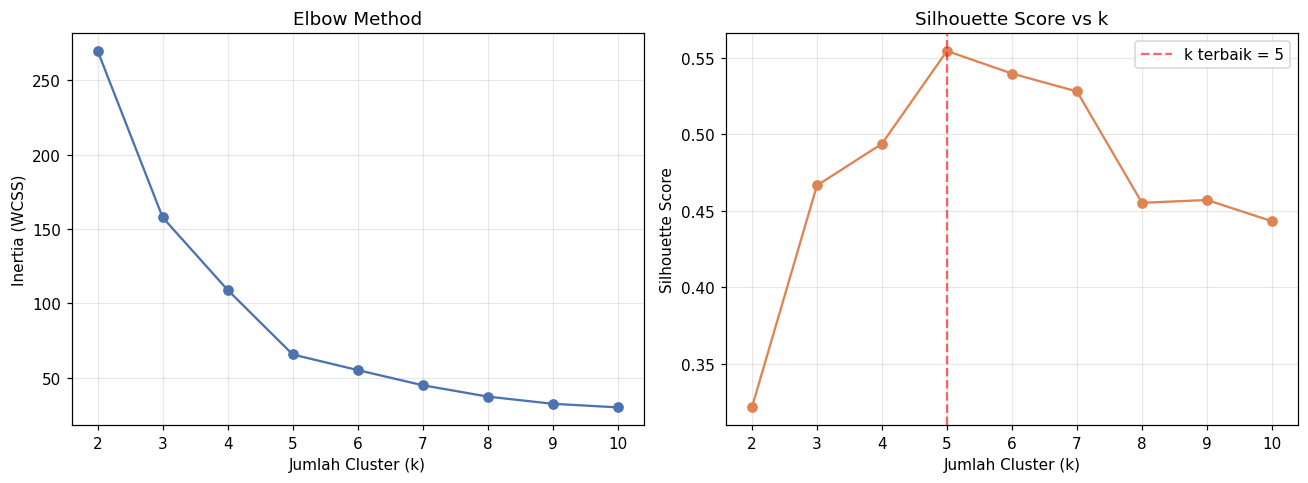

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(list(K_range), inertias, "o-", color="#4C72B0")
axes[0].set_xlabel("Jumlah Cluster (k)")
axes[0].set_ylabel("Inertia (WCSS)")
axes[0].set_title("Elbow Method")
axes[0].grid(alpha=0.3)

axes[1].plot(list(K_range), sil_scores, "o-", color="#DD8452")
axes[1].axvline(best_k, color="red", linestyle="--", alpha=0.6, label=f"k terbaik = {best_k}")
axes[1].set_xlabel("Jumlah Cluster (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score vs k")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [7]:
km_final = KMeans(n_clusters=best_k, init="k-means++", n_init=10, random_state=42)
df["Cluster"] = km_final.fit_predict(X_scaled)
final_sil = silhouette_score(X_scaled, df["Cluster"])
print(f"Model final: k={best_k}, silhouette score={final_sil:.4f}")

summary = df.groupby("Cluster")[features + ["Age"]].mean().round(2)
summary["Jumlah Pelanggan"] = df["Cluster"].value_counts().sort_index()
summary


Model final: k=5, silhouette score=0.5547


,Annual Income (k$),Spending Score (1-100),Age,Jumlah Pelanggan
Cluster,,,,
0,55.30,49.52,42.72,81
1,86.54,82.13,32.69,39
2,25.73,79.36,25.27,22
3,88.20,17.11,41.11,35
4,26.30,20.91,45.22,23


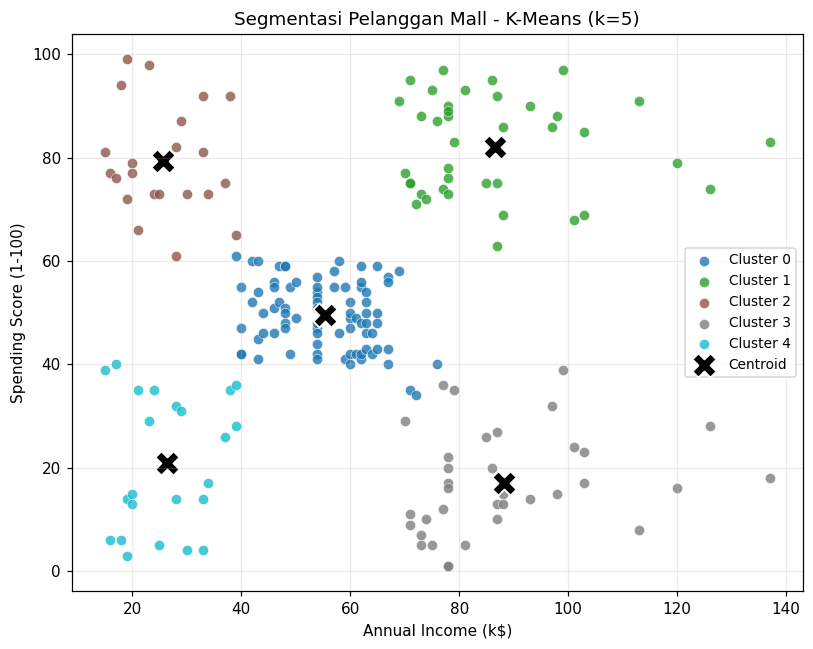

In [8]:
centers_original = scaler.inverse_transform(km_final.cluster_centers_)

plt.figure(figsize=(7.5, 6))
palette = plt.cm.tab10(np.linspace(0, 1, best_k))
for c in range(best_k):
    subset = df[df["Cluster"] == c]
    plt.scatter(subset[features[0]], subset[features[1]],
                s=45, color=palette[c], label=f"Cluster {c}", alpha=0.8,
                edgecolor="white", linewidth=0.4)
plt.scatter(centers_original[:, 0], centers_original[:, 1],
            s=250, c="black", marker="X", label="Centroid", edgecolor="white", linewidth=1.2)
plt.xlabel(features[0])
plt.ylabel(features[1])
plt.title(f"Segmentasi Pelanggan Mall - K-Means (k={best_k})")
plt.legend(loc="best", fontsize=9)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


In [9]:
df.to_csv("mall_customers_clustered.csv", index=False)
summary.to_csv("kmeans_cluster_summary.csv")
print("Tersimpan: mall_customers_clustered.csv, kmeans_cluster_summary.csv")


Tersimpan: mall_customers_clustered.csv, kmeans_cluster_summary.csv


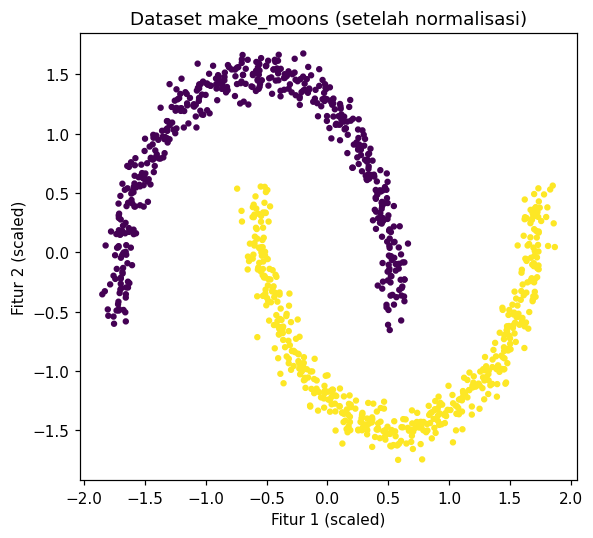

In [10]:
X_moons, y_true = make_moons(n_samples=1000, noise=0.05, random_state=42)

scaler_m = StandardScaler()
X_moons_scaled = scaler_m.fit_transform(X_moons)

plt.figure(figsize=(5.5, 5))
plt.scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1], s=10, c=y_true, cmap="viridis")
plt.title("Dataset make_moons (setelah normalisasi)")
plt.xlabel("Fitur 1 (scaled)")
plt.ylabel("Fitur 2 (scaled)")
plt.tight_layout()
plt.show()


In [11]:
db = DBSCAN(eps=0.2, min_samples=5)
labels = db.fit_predict(X_moons_scaled)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = int(np.sum(labels == -1))
print(f"Jumlah cluster: {n_clusters}")
print(f"Jumlah noise  : {n_noise}")


Jumlah cluster: 2
Jumlah noise  : 0


In [12]:
def evaluate(X_scaled, y_true, labels):
    hom = homogeneity_score(y_true, labels)
    com = completeness_score(y_true, labels)
    vms = v_measure_score(y_true, labels)
    ari = adjusted_rand_score(y_true, labels)
    ami = adjusted_mutual_info_score(y_true, labels)
    mask = labels != -1
    n_unique = len(set(labels[mask]))
    if n_unique >= 2 and mask.sum() > n_unique:
        sil = silhouette_score(X_scaled[mask], labels[mask])
    else:
        sil = np.nan
    return dict(homogeneity=hom, completeness=com, v_measure=vms,
                ari=ari, ami=ami, silhouette=sil)

base_metrics = evaluate(X_moons_scaled, y_true, labels)
print("Metrik evaluasi (eps=0.2, min_samples=5):")
for k, v in base_metrics.items():
    print(f"  {k}: {v:.4f}" if not np.isnan(v) else f"  {k}: nan")


Metrik evaluasi (eps=0.2, min_samples=5):
  homogeneity: 1.0000
  completeness: 1.0000
  v_measure: 1.0000
  ari: 1.0000
  ami: 1.0000
  silhouette: 0.3912


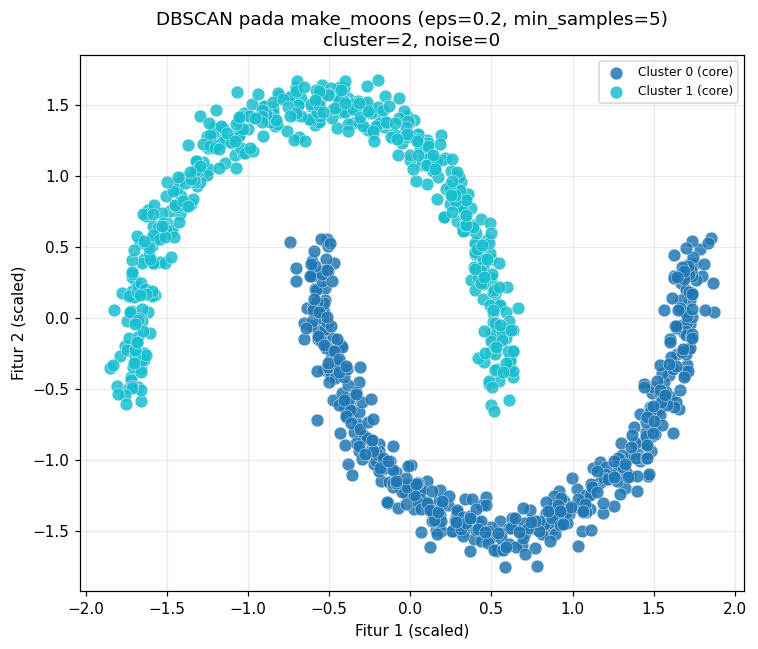

In [13]:
core_mask = np.zeros_like(labels, dtype=bool)
core_mask[db.core_sample_indices_] = True

plt.figure(figsize=(7, 6))
unique_labels = sorted(set(labels))
palette = plt.cm.tab10(np.linspace(0, 1, max(len(unique_labels), 2)))
color_map = {lab: (palette[i] if lab != -1 else (0, 0, 0, 1))
             for i, lab in enumerate([l for l in unique_labels if l != -1])}
color_map[-1] = (0, 0, 0, 1)

for lab in unique_labels:
    lab_mask = labels == lab
    color = color_map[lab]
    if lab == -1:
        plt.scatter(X_moons_scaled[lab_mask, 0], X_moons_scaled[lab_mask, 1],
                    s=15, c=[color], label="Noise", marker="x")
    else:
        is_core = lab_mask & core_mask
        is_border = lab_mask & ~core_mask
        plt.scatter(X_moons_scaled[is_core, 0], X_moons_scaled[is_core, 1],
                    s=70, c=[color], label=f"Cluster {lab} (core)", alpha=0.85,
                    edgecolor="white", linewidth=0.3)
        plt.scatter(X_moons_scaled[is_border, 0], X_moons_scaled[is_border, 1],
                    s=15, c=[color], alpha=0.85)

plt.title(f"DBSCAN pada make_moons (eps=0.2, min_samples=5)\ncluster={n_clusters}, noise={n_noise}")
plt.xlabel("Fitur 1 (scaled)")
plt.ylabel("Fitur 2 (scaled)")
plt.legend(loc="best", fontsize=8)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


In [14]:
eps_list = [0.05, 0.1, 0.2, 0.3, 0.5]
min_samples_list = [3, 5, 10, 20]

results = []
for eps in eps_list:
    for ms in min_samples_list:
        db_exp = DBSCAN(eps=eps, min_samples=ms)
        lab_exp = db_exp.fit_predict(X_moons_scaled)
        n_c = len(set(lab_exp)) - (1 if -1 in lab_exp else 0)
        n_n = int(np.sum(lab_exp == -1))
        m = evaluate(X_moons_scaled, y_true, lab_exp)
        results.append(dict(eps=eps, min_samples=ms, n_clusters=n_c, n_noise=n_n, **m))

res_df = pd.DataFrame(results)
res_df.round(3)


,eps,min_samples,n_clusters,n_noise,homogeneity,completeness,v_measure,ari,ami,silhouette
0,0.05,3,69,186,0.816,0.153,0.257,0.030,0.244,0.349
1,0.05,5,61,386,0.615,0.137,0.224,0.016,0.210,0.502
2,0.05,10,3,970,0.031,0.127,0.049,0.002,0.046,0.881
3,0.05,20,0,1000,0.000,1.000,0.000,0.000,0.000,NaN
4,0.10,3,2,14,0.986,0.903,0.943,0.972,0.943,0.394
5,0.10,5,3,19,0.981,0.633,0.769,0.758,0.769,0.378
6,0.10,10,7,57,0.943,0.410,0.571,0.523,0.570,0.210
7,0.10,20,6,850,0.154,0.155,0.155,0.017,0.151,0.787
8,0.20,3,2,0,1.000,1.000,1.000,1.000,1.000,0.391
9,0.20,5,2,0,1.000,1.000,1.000,1.000,1.000,0.391


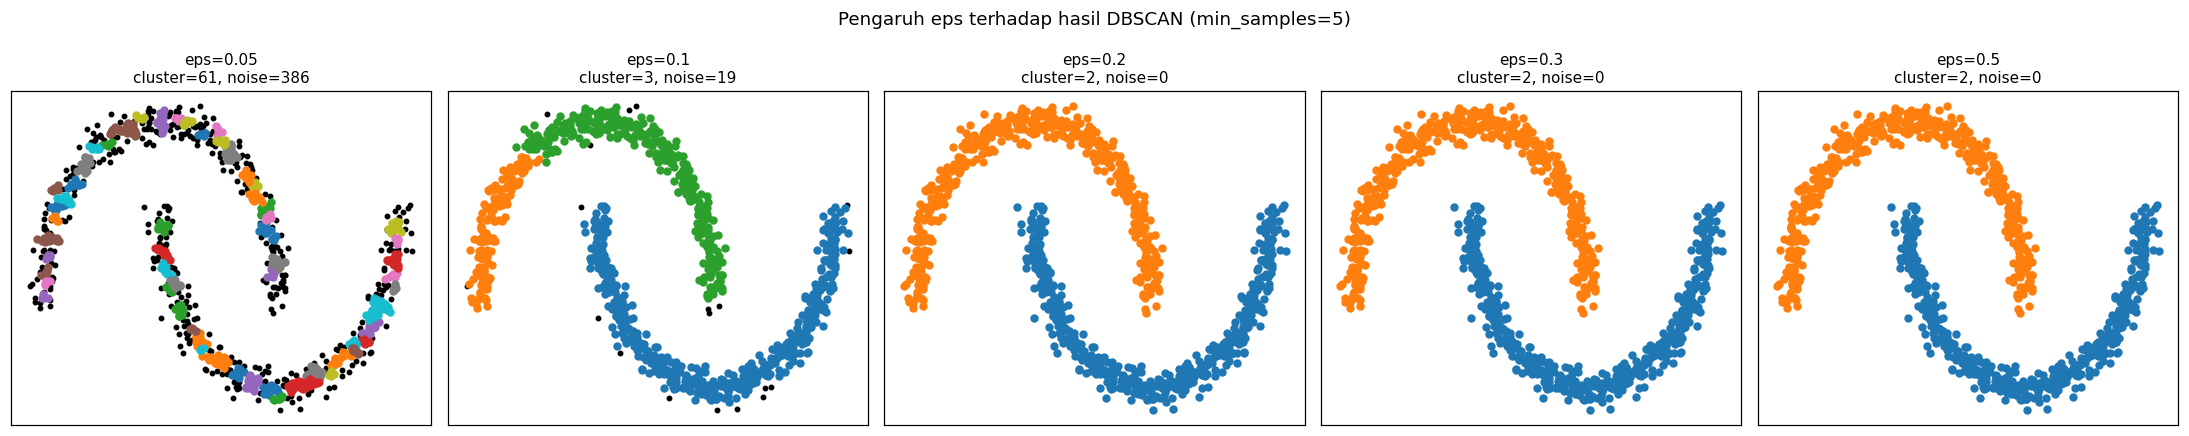

In [15]:
fig, axes = plt.subplots(1, len(eps_list), figsize=(4 * len(eps_list), 4))
for ax, eps in zip(axes, eps_list):
    db_exp = DBSCAN(eps=eps, min_samples=5)
    lab_exp = db_exp.fit_predict(X_moons_scaled)
    n_c = len(set(lab_exp)) - (1 if -1 in lab_exp else 0)
    n_n = int(np.sum(lab_exp == -1))
    for lab in sorted(set(lab_exp)):
        m = lab_exp == lab
        color = "black" if lab == -1 else plt.cm.tab10(lab % 10)
        s = 8 if lab == -1 else 20
        ax.scatter(X_moons_scaled[m, 0], X_moons_scaled[m, 1], s=s, c=[color])
    ax.set_title(f"eps={eps}\ncluster={n_c}, noise={n_n}", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Pengaruh eps terhadap hasil DBSCAN (min_samples=5)")
plt.tight_layout()
plt.show()


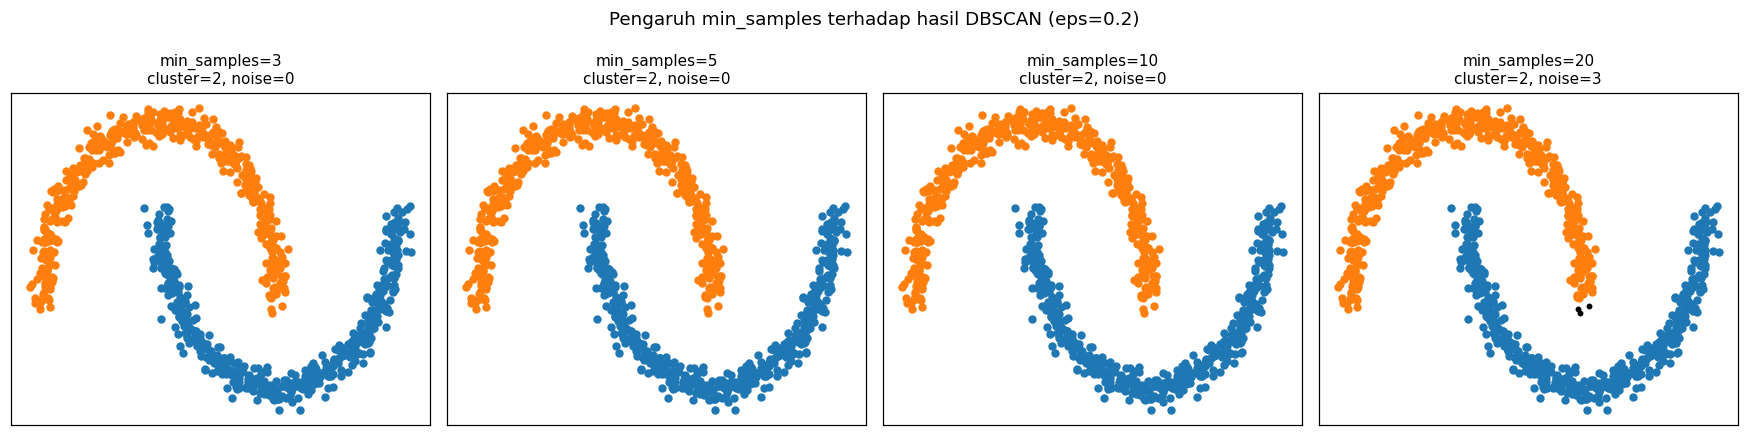

In [16]:
fig, axes = plt.subplots(1, len(min_samples_list), figsize=(4 * len(min_samples_list), 4))
for ax, ms in zip(axes, min_samples_list):
    db_exp = DBSCAN(eps=0.2, min_samples=ms)
    lab_exp = db_exp.fit_predict(X_moons_scaled)
    n_c = len(set(lab_exp)) - (1 if -1 in lab_exp else 0)
    n_n = int(np.sum(lab_exp == -1))
    for lab in sorted(set(lab_exp)):
        m = lab_exp == lab
        color = "black" if lab == -1 else plt.cm.tab10(lab % 10)
        s = 8 if lab == -1 else 20
        ax.scatter(X_moons_scaled[m, 0], X_moons_scaled[m, 1], s=s, c=[color])
    ax.set_title(f"min_samples={ms}\ncluster={n_c}, noise={n_n}", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Pengaruh min_samples terhadap hasil DBSCAN (eps=0.2)")
plt.tight_layout()
plt.show()


In [17]:
res_df.to_csv("dbscan_experiment_results.csv", index=False)
print("Tersimpan: dbscan_experiment_results.csv")


Tersimpan: dbscan_experiment_results.csv
